## profilage_bofip_consolide

**Fichier(s) source :** `./data/bofip_stock_live_20260521.tgz`

**Fichier(s) de sortie :** DataFrame en mémoire

**Description :** Profiling exploratoire et consolidé du corpus BOFiP (stock du 21 mai 2026) : lecture de l'archive, extraction des métadonnées Dublin Core (document.xml) et synthèse par dimension de qualité (représentativité, fraîcheur, renvois, longueurs pour le chunking).

In [1]:
# === CELLULE 1 — Configuration (le seul réglage à changer) ===
import os, tarfile, re
from datetime import datetime
import pandas as pd
import xml.etree.ElementTree as ET

# (a) L'archive à analyser — change CETTE ligne pour passer du stock au flux
ARCHIVE = r"./data/bofip_stock_live_20260521.tgz"

# (b) La racine des sorties — sœur du corpus, jamais le corpus lui-même
RACINE_ANALYSES = r"./outputs"

# (c) Dossier de CETTE exécution : <racine>\<nom_archive>\run_<horodatage>
stem = os.path.splitext(os.path.basename(ARCHIVE))[0]      # ex. bofip_stock_live_20260521
run_stamp = datetime.now().strftime("run_%Y%m%d_%H%M%S")
DOSSIER_RUN = os.path.join(RACINE_ANALYSES, stem, run_stamp)
os.makedirs(DOSSIER_RUN, exist_ok=True)

print("Archive analysée        :", os.path.basename(ARCHIVE))
print("Sorties de cette exécution :", DOSSIER_RUN)

Archive analysée        : bofip_stock_live_20260521.tgz
Sorties de cette exécution : ./outputs/bofip_stock_live_20260521/run_TIMESTAMP


In [2]:
# === CELLULE 2 — Outils de lecture d'un document (définit des fonctions, peu de sortie) ===

def localname(tag):
    """Enlève l'espace de noms d'une balise XML : '{...}date' -> 'date'."""
    return tag.rsplit('}', 1)[-1]

def parse_xml(octets):
    """Lit le document.xml d'un document BOFiP et en extrait les métadonnées utiles."""
    root = ET.fromstring(octets)
    d = {"dc_date": None, "node_id": None, "boi_code": None,
         "niveau": None, "type": None, "relations": [], "subjects": []}
    for el in root.iter():
        ln = localname(el.tag)
        t = (el.text or "").strip()
        if ln == "date" and not d["dc_date"]:
            d["dc_date"] = t
        elif ln == "identifier" and t.endswith("-PGP") and not d["node_id"]:
            d["node_id"] = t
        elif ln == "contenu_id" and not d["boi_code"]:
            d["boi_code"] = t
        elif ln == "contenu_niveau":
            d["niveau"] = t
        elif ln == "contenu_type":
            d["type"] = t
        elif ln == "relation" and t:
            d["relations"].append(t)
        elif ln == "subject" and t:
            d["subjects"].append(t)
    return d

print("Outils définis : localname() et parse_xml().")

Outils définis : localname() et parse_xml().


In [3]:
# === CELLULE 3 — Lecture de tout le corpus ===
from collections import Counter

recs = []
present = set()
categories      = Counter()
extensions_data = Counter()
nb_dtd = 0

with tarfile.open(ARCHIVE, "r:gz") as tar:
    par_dossier = {}
    for m in tar.getmembers():
        if not m.isfile():
            continue
        base = os.path.basename(m.name)
        par_dossier.setdefault(os.path.dirname(m.name), {})[base] = m
        if base.startswith("data."):
            extensions_data[os.path.splitext(base)[1].lower()] += 1
        if base.lower().endswith(".dtd"):
            nb_dtd += 1

    # 1) Tous les identifiants réellement présents (dossiers ayant un document.xml)
    for dossier, fichiers in par_dossier.items():
        if "document.xml" in fichiers:
            segs = dossier.split("/")
            if len(segs) >= 2:
                present.add(segs[-2])
                for cat in ("Contenu", "Actualite", "Actualité", "Fichier"):
                    if cat in segs:
                        categories[cat.replace("Actualité", "Actualite")] += 1
                        break

    # 2) Inventaire des documents de Contenu
    for dossier, fichiers in par_dossier.items():
        segs = dossier.split("/")
        if "Contenu" not in segs or "document.xml" not in fichiers:
            continue
        meta = parse_xml(tar.extractfile(fichiers["document.xml"]).read())
        texte = (tar.extractfile(fichiers["data.html"]).read().decode("utf-8", "replace")
                 if "data.html" in fichiers else "")

        # renvois TYPÉS (la clé de la racine commune D10+D11)
        orph = {"Actualite": 0, "Contenu": 0, "Fichier": 0, "Autre": 0}
        nb_orph = 0
        for r in meta["relations"]:
            typ   = r.split(":")[0] if ":" in r else "Autre"
            ident = r.split(":")[-1]
            if ident not in present:
                nb_orph += 1
                orph[typ if typ in orph else "Autre"] += 1

        boi = meta["boi_code"] or ""
        boi_base = re.sub(r"-\d{8}$", "", boi)

        i = segs.index("Contenu")
        recs.append({
            "identifiant": segs[-2],
            "serie": segs[i+2] if len(segs) > i+2 else None,
            "sujets": " | ".join(meta["subjects"]),
            "type": meta["type"], "niveau": meta["niveau"],
            "date_publication": meta["dc_date"],
            "annee": (meta["dc_date"][:4] if meta["dc_date"] else None),
            "boi_code": boi, "boi_base": boi_base,
            "nb_renvois": len(meta["relations"]),
            "nb_orphelins": nb_orph,
            "orph_actualite": orph["Actualite"],
            "orph_contenu":   orph["Contenu"],
            "orph_fichier":   orph["Fichier"],
            "date_affichee_cassee": len(re.findall(r"\[node:date[^\]]*\]", texte)) > 0,
            "longueur_html": len(texte),
            "nb_ancres_chunk": len(re.findall(r'\b(?:id|name)=', texte)),
        })

df = pd.DataFrame(recs)
print(len(df), "documents de contenu analysés.")
print("\nRecensement des types de fichiers :")
print("  Catégories de dossiers :", dict(categories))
print("  Extensions de contenu  :", dict(extensions_data))
print("  Fichiers DTD           :", nb_dtd)
df.head(5)

6311 documents de contenu analysés.

Recensement des types de fichiers :
  Catégories de dossiers : {'Contenu': 6311}
  Extensions de contenu  : {'.html': 6311, '.xml': 1, '.dtd': 1}
  Fichiers DTD           : 3


,identifiant,serie,sujets,type,niveau,date_publication,annee,boi_code,boi_base,nb_renvois,nb_orphelins,orph_actualite,orph_contenu,orph_fichier,date_affichee_cassee,longueur_html,nb_ancres_chunk
0,1000-PGP,TVA,TVA | DECLA,Commentaire,Parent,2023-01-18,2023,BOI-TVA-DECLA-20-20-30-20230118,BOI-TVA-DECLA-20-20-30,4,0,0,0,0,False,3603,19
1,1001-PGP,TVA,TVA | DECLA,Commentaire,Enfant,2023-01-18,2023,BOI-TVA-DECLA-20-20-10-10-20230118,BOI-TVA-DECLA-20-20-10-10,6,1,1,0,0,False,27473,124
2,1007-PGP,TVA,TVA | CHAMP,Commentaire,Enfant,2022-03-23,2022,BOI-TVA-CHAMP-30-10-30-30-20220323,BOI-TVA-CHAMP-30-10-30-30,12,3,1,2,0,False,45726,212
3,1009-PGP,TVA,TVA | CHAMP,Commentaire,Enfant,2019-05-15,2019,BOI-TVA-CHAMP-30-10-30-20-20190515,BOI-TVA-CHAMP-30-10-30-20,6,0,0,0,0,False,48510,240
4,1010-PGP,TVA,TVA | CHAMP,Commentaire,Enfant,2025-04-16,2025,BOI-TVA-CHAMP-30-10-30-10-20250416,BOI-TVA-CHAMP-30-10-30-10,12,1,1,0,0,True,58700,233


In [4]:
# === Répartition par type de contenu, et par niveau pour les Commentaires ===
from IPython.display import display

display(df["type"].value_counts())
display(df.loc[df["type"] == "Commentaire", "niveau"].value_counts())

type
Commentaire           5679
Autres annexes         306
Lettre Type/Modèle     201
Formulaire              84
Barème                  36
Cartographie             5
Name: count, dtype: int64

niveau
Enfant    4226
Parent    1447
Name: count, dtype: int64

In [5]:
# === CELLULE 4 — Synthèse par dimension ===

# Division tirée de dc:subject (format observé en cellule 3 : "SERIE | DIVISION")
df["division"] = df["sujets"].apply(lambda s: s.split("|")[1].strip() if "|" in str(s) else None)

kind = "STOCK (corpus complet)" if "stock" in os.path.basename(ARCHIVE).lower() else "FLUX (livraison hebdomadaire)"
print("Archive :", kind, "|", len(df), "documents de contenu\n")

# --- Complétude des métadonnées de routage ---
print("=== Complétude des métadonnées de routage ===")
type_ok = df["type"].notna().sum()
sujets_ok = (df["sujets"] != "").sum()
niveau_vide = (df["niveau"].isna() | (df["niveau"] == "")).sum()
print(f"bofip:contenu_type renseigné : {type_ok} / {len(df)} ({type_ok/len(df):.1%})")
print(f"dc:subject renseigné : {sujets_ok} / {len(df)} ({sujets_ok/len(df):.1%})")
print(f"bofip:contenu_niveau vide : {niveau_vide} / {len(df)}")
# Quels documents n'ont pas de dc:subject ?
sans_sujet = df[df["sujets"] == ""]
print(f"\nDocuments sans dc:subject ({len(sans_sujet)}) :")
print(sans_sujet[["identifiant", "type", "niveau", "serie", "date_publication", "boi_code"]].to_string(index=False))

# --- D8 Représentativité ---
print("\n=== D8 Représentativité ===")
print("Séries :", df["serie"].nunique(), "| Divisions :", df["division"].nunique())
print("Répartition par série (top 10) :")
print(df["serie"].value_counts().head(10).to_string())
parts = df["serie"].value_counts(normalize=True)
print(f"Concentration : série dominante = {parts.iloc[0]:.1%} ; top 3 = {parts.head(3).sum():.1%}")

# --- D11 Fraîcheur / actualité ---
print("\n=== D11 Fraîcheur / actualité ===")
print("Répartition par année de publication :")
print(df["annee"].value_counts().sort_index().to_string())
an = pd.to_numeric(df["annee"], errors="coerce")
anciens = int((an < 2020).sum())
print(f"Publiés avant 2020 : {anciens} ({anciens/len(df):.1%})")
casse = int(df["date_affichee_cassee"].sum())
print(f"Documents à date affichée cassée : {casse} ({casse/len(df):.1%})")
df_boi = df[df["boi_base"] != ""]
versions = df_boi.groupby("boi_base")["boi_code"].nunique()
multi = versions[versions > 1]
docs_multi = int(df_boi["boi_base"].isin(multi.index).sum())
print(f"Textes en plusieurs versions datées : {len(multi)} ({docs_multi} documents concernés)")

# --- D10 Compréhensibilité — renvois ---
print("\n=== D10 Compréhensibilité — renvois ===")
tot_r = int(df["nb_renvois"].sum()); tot_o = int(df["nb_orphelins"].sum())
print(f"Renvois non résolus : {tot_o} sur {tot_r} ({tot_o/max(tot_r,1):.1%})")
print(f"Documents touchés : {int((df['nb_orphelins']>0).sum())}")
print("Orphelins par type :",
      {"Actualite": int(df['orph_actualite'].sum()),
       "Contenu":   int(df['orph_contenu'].sum()),
       "Fichier":   int(df['orph_fichier'].sum())})

# --- Racine commune D10 + D11 (l'Actualité absente) ---
print("\n=== Racine commune D10+D11 ===")
dc = df[df["date_affichee_cassee"]]
if len(dc):
    print(f"Documents à date cassée : {len(dc)}")
    print(f"  dont avec un renvoi Actualité orphelin : {(dc['orph_actualite']>0).mean():.1%}")

# --- Caractérisation pour le chunking (D10) ---
print("\n=== Caractérisation pour le chunking ===")
print("Longueur HTML (caractères) :")
print(df["longueur_html"].describe().round(0).to_string())
print("Longueur médiane par type / niveau :")
print(df.groupby(["type","niveau"])["longueur_html"].median().round(0).to_string())

Archive : STOCK (corpus complet) | 6311 documents de contenu

=== Complétude des métadonnées de routage ===
bofip:contenu_type renseigné : 6311 / 6311 (100.0%)
dc:subject renseigné : 6305 / 6311 (99.9%)
bofip:contenu_niveau vide : 573 / 6311

Documents sans dc:subject (6) :
identifiant        type niveau serie date_publication                   boi_code
   7362-PGP Commentaire   None Autre       2012-09-12   BOI-ANNX-000000-20120912
   7363-PGP Commentaire   None Autre       2012-09-12  BOI-CARTE-000000-20120912
   7364-PGP Commentaire   None Autre       2012-09-12 BOI-LETTRE-000000-20120912
   7365-PGP Commentaire   None Autre       2012-09-12   BOI-FORM-000000-20120912
   7366-PGP Commentaire   None Autre       2012-09-12 BOI-BAREME-000000-20120912
   7367-PGP Commentaire   None Autre       2012-09-12       BOI-ANNEXES-20120912

=== D8 Représentativité ===
Séries : 29 | Divisions : 187
Répartition par série (top 10) :
serie
BIC     799
TVA     556
IS      550
IF      523
IR      460


Inventaire : ./outputs/bofip_stock_live_20260521/run_TIMESTAMP/inventaire_bofip_stock_live_20260521.csv + .xlsx
Synthèse : ./outputs/bofip_stock_live_20260521/run_TIMESTAMP/synthese_bofip_stock_live_20260521.md


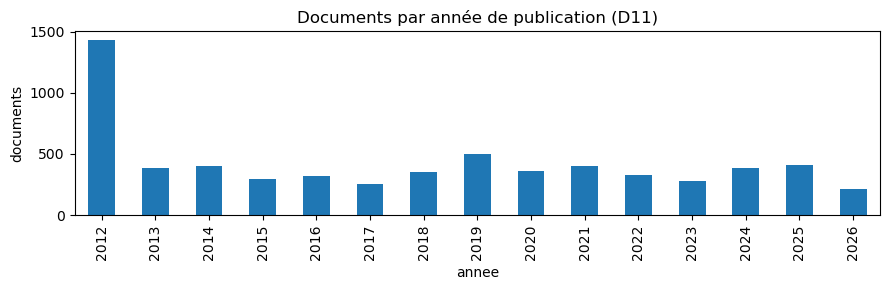

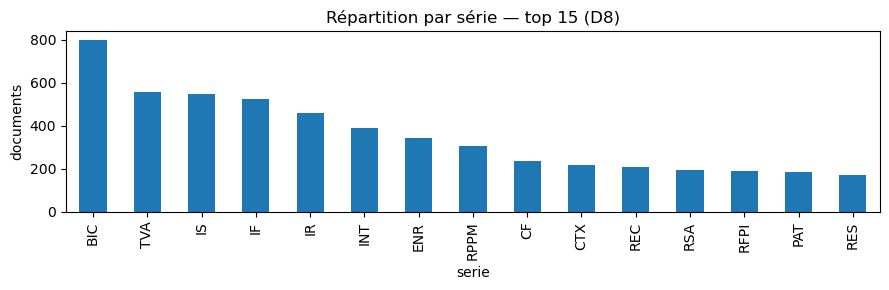

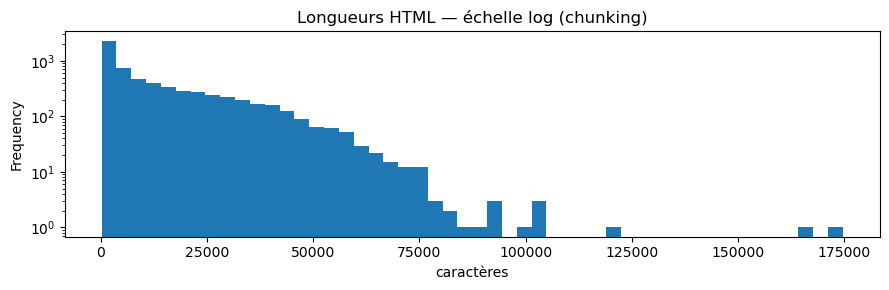

Figures dans : ./outputs/bofip_stock_live_20260521/run_TIMESTAMP/figures


In [6]:
# === CELLULE 5 — Exports (inventaire, synthèse, figures) ===
import matplotlib.pyplot as plt

stem = os.path.splitext(os.path.basename(ARCHIVE))[0]
dossier_fig = os.path.join(DOSSIER_RUN, "figures"); os.makedirs(dossier_fig, exist_ok=True)

# 1) Inventaire complet
csv_path  = os.path.join(DOSSIER_RUN, f"inventaire_{stem}.csv")
xlsx_path = os.path.join(DOSSIER_RUN, f"inventaire_{stem}.xlsx")
df.to_csv(csv_path, index=False, encoding="utf-8-sig")
try:
    df.to_excel(xlsx_path, index=False); print("Inventaire :", csv_path, "+ .xlsx")
except Exception as e:
    print("CSV exporté (xlsx ignoré :", e, ")")

# 2) Synthèse markdown
an = pd.to_numeric(df["annee"], errors="coerce")
parts = df["serie"].value_counts(normalize=True)
df_boi = df[df["boi_base"] != ""]; versions = df_boi.groupby("boi_base")["boi_code"].nunique()
tot_r = int(df["nb_renvois"].sum()); tot_o = int(df["nb_orphelins"].sum()); dc = df[df["date_affichee_cassee"]]
md = f"""# Synthèse — {stem}
Documents : {len(df)} | Séries : {df['serie'].nunique()} | Divisions : {df['division'].nunique()}

## D8 Représentativité
Série dominante {parts.iloc[0]:.1%} ; top 3 {parts.head(3).sum():.1%}

## D11 Fraîcheur
Avant 2020 : {int((an<2020).sum())} ({(an<2020).mean():.1%}) — âge, pas obsolescence
Dates cassées : {int(df['date_affichee_cassee'].sum())} ({df['date_affichee_cassee'].mean():.1%})
Textes en versions multiples : {int((versions>1).sum())}

## D10 Renvois
Non résolus : {tot_o}/{tot_r} ({tot_o/max(tot_r,1):.1%}) ; documents touchés {int((df['nb_orphelins']>0).sum())}
Orphelins — Actualité {int(df['orph_actualite'].sum())}, Contenu {int(df['orph_contenu'].sum())}, Fichier {int(df['orph_fichier'].sum())}

## Racine commune D10+D11
Sur {len(dc)} docs à date cassée, {(dc['orph_actualite']>0).mean():.1%} ont aussi un renvoi Actualité orphelin

## Chunking
Longueur médiane {int(df['longueur_html'].median())} car. (min {int(df['longueur_html'].min())}, max {int(df['longueur_html'].max())})
"""
md_path = os.path.join(DOSSIER_RUN, f"synthese_{stem}.md")
open(md_path, "w", encoding="utf-8").write(md); print("Synthèse :", md_path)

# 3) Figures
df["annee"].value_counts().sort_index().plot(kind="bar", figsize=(9,3),
    title="Documents par année de publication (D11)"); plt.ylabel("documents"); plt.tight_layout()
plt.savefig(os.path.join(dossier_fig, "age.png"), dpi=110); plt.show()

df["serie"].value_counts().head(15).plot(kind="bar", figsize=(9,3),
    title="Répartition par série — top 15 (D8)"); plt.ylabel("documents"); plt.tight_layout()
plt.savefig(os.path.join(dossier_fig, "series.png"), dpi=110); plt.show()

df["longueur_html"].plot(kind="hist", bins=50, logy=True, figsize=(9,3),
    title="Longueurs HTML — échelle log (chunking)"); plt.xlabel("caractères"); plt.tight_layout()
plt.savefig(os.path.join(dossier_fig, "longueurs.png"), dpi=110); plt.show()

print("Figures dans :", dossier_fig)

In [7]:
# === CELLULE 6 — Inspection d'un document précis (cas spécial) ===
# Change l'ID pour inspecter un autre document :
#   "1007-PGP" -> renvois Contenu orphelins (lacune doctrinale)
#   "1010-PGP" -> date affichée cassée (jeton [node:date])
ID = "1007-PGP"

dossier_insp = os.path.join(DOSSIER_RUN, "documents_inspectes", ID)
os.makedirs(dossier_insp, exist_ok=True)

ligne = df[df["identifiant"] == ID]
if len(ligne):
    r = ligne.iloc[0]
    print(f"{ID} — série {r['serie']} / division {r['division']} | {r['type']} {r['niveau']} | "
          f"publié {r['date_publication']} | {r['boi_code']}")
    print(f"  renvois {r['nb_renvois']}, orphelins {r['nb_orphelins']} "
          f"(Actualité {r['orph_actualite']}, Contenu {r['orph_contenu']}, Fichier {r['orph_fichier']}) "
          f"| date cassée : {r['date_affichee_cassee']}\n")

with tarfile.open(ARCHIVE, "r:gz") as tar:
    present_ids = set(); cible_xml = cible_html = None
    for m in tar.getmembers():
        if m.name.endswith("document.xml"):
            segs = os.path.dirname(m.name).split("/")
            if len(segs) >= 2: present_ids.add(segs[-2])
        if ("/" + ID + "/") in (m.name + "/"):
            if m.name.endswith("document.xml"): cible_xml = m
            if m.name.endswith("data.html"):    cible_html = m

    if cible_xml is None and cible_html is None:
        print("Identifiant introuvable :", ID)
    if cible_xml is not None:
        data = tar.extractfile(cible_xml).read()
        open(os.path.join(dossier_insp, "document.xml"), "wb").write(data)
        txt = data.decode("utf-8", "replace")
        renvois = re.findall(r"<dc:relation[^>]*>(.*?)</dc:relation>", txt)
        print(f"RENVOIS de {ID} :")
        absents = 0
        for rv in renvois:
            ok = rv.split(":")[-1] in present_ids
            if not ok: absents += 1
            print(f"  {'présent' if ok else 'ABSENT '}  {rv}")
        print(f"  -> {len(renvois)} renvois, dont {absents} orphelins.\n")
    if cible_html is not None:
        data = tar.extractfile(cible_html).read()
        open(os.path.join(dossier_insp, "data.html"), "wb").write(data)
        txt = data.decode("utf-8", "replace")
        lignes = [l.strip() for l in txt.splitlines() if "[node:" in l]
        print("LIGNES à jeton cassé [node:...] :")
        for l in (lignes[:5] or ["  (aucune)"]): print("  -", l[:180] if lignes else l)
print("\nFichiers extraits dans :", dossier_insp)

1007-PGP — série TVA / division CHAMP | Commentaire Enfant | publié 2022-03-23 | BOI-TVA-CHAMP-30-10-30-30-20220323
  renvois 12, orphelins 3 (Actualité 1, Contenu 2, Fichier 0) | date cassée : False

RENVOIS de 1007-PGP :
  présent  Contenu:1010-PGP
  présent  Contenu:126-PGP
  ABSENT   Actualite:13498-PGP
  ABSENT   Contenu:13825-PGP
  ABSENT   Contenu:13826-PGP
  présent  Contenu:162-PGP
  présent  Contenu:203-PGP
  présent  Contenu:2358-PGP
  présent  Contenu:4343-PGP
  présent  Contenu:6844-PGP
  présent  Contenu:935-PGP
  présent  Contenu:943-PGP
  -> 12 renvois, dont 3 orphelins.

LIGNES à jeton cassé [node:...] :
  -   (aucune)

Fichiers extraits dans : ./outputs/bofip_stock_live_20260521/run_TIMESTAMP/documents_inspectes/1007-PGP
